What is SVM?

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression. It finds the optimal hyperplane that maximizes the margin between different classes.

What is a Hyperplane?

A hyperplane is the decision boundary used by SVM to separate different classes. It is a point in 1D, a line in 2D, a plane in 3D, and a higher-dimensional flat surface in higher dimensions.

Margin:

The margin is the distance between the hyperplane and the nearest data points from each class.

Why does SVM maximize the margin?

A larger margin usually leads to better generalization, making the model less sensitive to small changes or noise in unseen data.


What happens if we remove non-support vectors?

Usually, the decision boundary remains almost unchanged because those points are not defining the margin.

What happens if we remove support vectors?

The decision boundary can change significantly because the model loses the points that define the optimal hyperplane.

In [13]:
#Import lib:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib
from IPython.display import display

In [14]:
data = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\diabetes_2.csv")

display("Shape:", data.shape)

data.head()

'Shape:'

(768, 9)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [15]:
display(data.info())
display(data.describe())
display(data["Outcome"].value_counts())
display(data["Outcome"].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


0    500
1    268
Name: Outcome, dtype: int64

0    65.104167
1    34.895833
Name: Outcome, dtype: float64

In [17]:
# Missing values:
misisng_data = data.isnull().sum()
display(misisng_data)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [20]:
# data with zero values:
(data==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [23]:
zerovalue_percentage = (
    (data==0).sum() / len(data) * 100
)

display(zerovalue_percentage)

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

In [24]:
# Duplicates:
display(data.duplicated().sum())

0

In [25]:
# Convert Impossible Zeros to Missing
zero_cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[zero_cols]=data[zero_cols].replace(0,np.nan)

In [27]:
display(data.head())
(data==0).sum()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [28]:
X = data.drop("Outcome", axis=1)

y = data["Outcome"]

In [29]:
display("X shape:", X.shape)
display("y shape:", y.shape)

'X shape:'

(768, 8)

'y shape:'

(768,)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Build Linear SVM Pipeline

In [31]:
linear_svm_pipeline = Pipeline([
    
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "model",
        SVC(
            kernel="linear",
            probability=True,
            random_state=42
        )
    )
])

In [32]:
# train linear SVM:
linear_svm_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 SVC(kernel='linear', probability=True, random_state=42))])

In [33]:
# prediction:
linear_predictions = linear_svm_pipeline.predict(X_test)

linear_probabilities = (
    linear_svm_pipeline.predict_proba(X_test)[:, 1]
)

In [34]:
# Evaluate linear SVM:
linear_accuracy = accuracy_score(
    y_test,
    linear_predictions
)

linear_precision = precision_score(
    y_test,
    linear_predictions
)

linear_recall = recall_score(
    y_test,
    linear_predictions
)

linear_f1 = f1_score(
    y_test,
    linear_predictions
)

linear_roc_auc = roc_auc_score(
    y_test,
    linear_probabilities
)

print("Linear SVM Results")
print("-------------------")
print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1 Score :", linear_f1)
print("ROC-AUC  :", linear_roc_auc)

Linear SVM Results
-------------------
Accuracy : 0.7012987012987013
Precision: 0.5909090909090909
Recall   : 0.48148148148148145
F1 Score : 0.5306122448979591
ROC-AUC  : 0.8131481481481482


In [35]:
cm = confusion_matrix(
    y_test,
    linear_predictions
)

print(cm)

[[82 18]
 [28 26]]


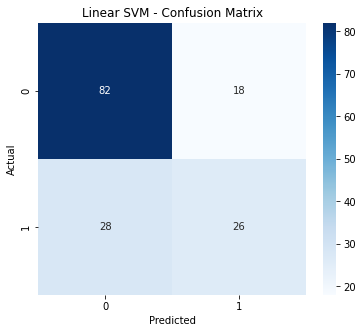

In [36]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Confusion Matrix")

plt.show()

In [37]:
print(
    classification_report(
        y_test,
        linear_predictions
    )
)

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



In [38]:
# Cross validatiion:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

We use StratifiedKFold in Cross-Validation mainly for classification problems when the target classes are imbalanced or we want every fold to have a similar class distribution.

In [41]:
cv_scores = cross_val_score(
    linear_svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("CV accuracy scores:", cv_scores)

print("Mean CV accuracy:", cv_scores.mean())

print("Std CV accuracy:", cv_scores.std())

CV accuracy scores: [0.78861789 0.7804878  0.81300813 0.79674797 0.76229508]
Mean CV accuracy: 0.7882313741170198
Std CV accuracy: 0.016847691267536723


In [40]:
cv_scores = cross_val_score(
    linear_svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("CV ROC-AUC scores:", cv_scores)

print("Mean CV ROC-AUC:", cv_scores.mean())

print("Std CV ROC-AUC:", cv_scores.std())

CV ROC-AUC scores: [0.78861789 0.7804878  0.81300813 0.79674797 0.76229508]
Mean CV ROC-AUC: 0.7882313741170198
Std CV ROC-AUC: 0.016847691267536723


# Build RBF SVM

RBF is usually much more powerful when the relationship between features and target is nonlinear.

In [42]:
rbf_svm_pipeline = Pipeline([
    
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "model",
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        )
    )
])

In [43]:
rbf_svm_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', SVC(probability=True, random_state=42))])

In [44]:
# RBF predictions:
rbf_predictions = rbf_svm_pipeline.predict(X_test)

rbf_probabilities = (
    rbf_svm_pipeline.predict_proba(X_test)[:, 1]
)

In [45]:
# RBF evaluation:
rbf_accuracy = accuracy_score(
    y_test,
    rbf_predictions
)

rbf_precision = precision_score(
    y_test,
    rbf_predictions
)

rbf_recall = recall_score(
    y_test,
    rbf_predictions
)

rbf_f1 = f1_score(
    y_test,
    rbf_predictions
)

rbf_roc_auc = roc_auc_score(
    y_test,
    rbf_probabilities
)

print("RBF SVM Results")
print("----------------")
print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1 Score :", rbf_f1)
print("ROC-AUC  :", rbf_roc_auc)

RBF SVM Results
----------------
Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1 Score : 0.6
ROC-AUC  : 0.7963888888888889


In [46]:
# Compare Linear Vs RBF:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    
    "Linear SVM": [
        linear_accuracy,
        linear_precision,
        linear_recall,
        linear_f1,
        linear_roc_auc
    ],
    
    "RBF SVM": [
        rbf_accuracy,
        rbf_precision,
        rbf_recall,
        rbf_f1,
        rbf_roc_auc
    ]
})

comparison

,Metric,Linear SVM,RBF SVM
0,Accuracy,0.701299,0.740260
1,Precision,0.590909,0.652174
2,Recall,0.481481,0.555556
3,F1,0.530612,0.600000
4,ROC-AUC,0.813148,0.796389


## Hyperparameter Tuning

We want to tune:

C

gamma

For RBF SV

In [ ]:
param_grid = {
    "model__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],
    
    "model__gamma": [
        "scale",
        0.001,
        0.01,
        0.1,
        1
    ]
}

## GridSearchCV

In [51]:
grid_search = GridSearchCV(
    estimator=rbf_svm_pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [52]:
# train:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('imputer',
                                        SimpleImputer(strategy='median')),
                                       ('scaler', StandardScaler()),
                                       ('model',
                                        SVC(probability=True,
                                            random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__gamma': ['scale', 0.001, 0.01, 0.1, 1]},
             scoring='accuracy', verbose=1)

In [53]:
# best parameters:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 100, 'model__gamma': 0.001}


In [55]:
# Best accuracy score:
print(
    "Best CV Accuracy:",
    grid_search.best_score_
)

Best CV Accuracy: 0.791483406637345


In [57]:
# best model:
best_svm = grid_search.best_estimator_
display(best_svm)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 SVC(C=100, gamma=0.001, probability=True, random_state=42))])

In [58]:
# final test prediction:
final_predictions = best_svm.predict(X_test)

final_probabilities = (
    best_svm.predict_proba(X_test)[:, 1]
)

In [59]:
# final evaluation:
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities
)

print("Final SVM Results")
print("=================")

print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

Final SVM Results
Accuracy : 0.6948051948051948
Precision: 0.5777777777777777
Recall   : 0.48148148148148145
F1 Score : 0.5252525252525252
ROC-AUC  : 0.8166666666666667


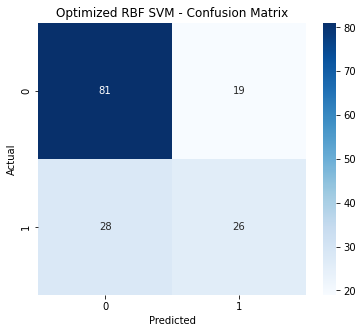

In [60]:
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Optimized RBF SVM - Confusion Matrix")

plt.show()

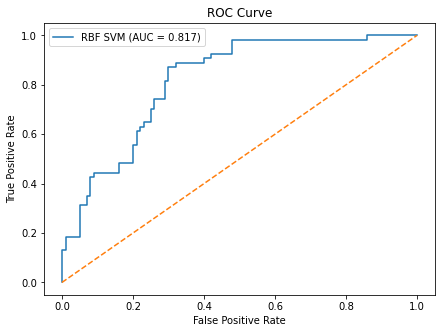

In [61]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"RBF SVM (AUC = {final_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [62]:
# save the complete pipeline:
joblib.dump(
    best_svm,
    "svm_diabetes_pipeline.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [63]:
# Load the Model:
loaded_svm = joblib.load(
    "svm_diabetes_pipeline.pkl"
)

In [64]:
# test loaded model:
loaded_predictions = loaded_svm.predict(
    X_test
)

print(
    "Loaded model accuracy:",
    accuracy_score(
        y_test,
        loaded_predictions
    )
)

Loaded model accuracy: 0.6948051948051948


In [65]:
# predict a new patient:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [145],
    "BloodPressure": [82],
    "SkinThickness": [20],
    "Insulin": [120],
    "BMI": [31.5],
    "DiabetesPedigreeFunction": [0.45],
    "Age": [42]
})

In [67]:
prediction = loaded_svm.predict(
    new_patient
)

probability = loaded_svm.predict_proba(
    new_patient
)[:, 1]

In [68]:
if prediction[0] == 1:
    print("Prediction: Diabetes")
else:
    print("Prediction: No Diabetes")

print(
    f"Diabetes probability: {probability[0]:.2%}"
)

Prediction: No Diabetes
Diabetes probability: 47.29%
